# Location Selection with E-NAUTILUS: Part 2
_Running of E-NAUTILUS for decision making, and presentation of results_


In [41]:
import numpy as np
import pandas as pd
import polars as pl
import pickle
import folium
# These are to just suppress warnings in the outputs of the example
import warnings

warnings.filterwarnings("ignore")

data_home = "../../data"

## Load results from previous session

In [42]:
file_name = f"{data_home}/pf_test.pkl"

output = open(file_name, 'rb')
prev_session = pickle.load(output)

raw_ref_pf = prev_session["pf"]
prob = prev_session["prob"]
sites = prev_session["sites"]
cities = prev_session["cities"]
cities_adj2sites = prev_session["cities_adj2sites"]
total_pop = prev_session["total_pop"]


EOFError: Ran out of input

## Load reference front and problem 

In [ ]:

output_flat = np.array(raw_ref_pf).flatten()

def process_lists(dict2conv):
    return {key: np.array(dict2conv[key]).flatten().tolist() for key in dict2conv.keys()}

# TODO include constraints in here too
output_dict = [
    output.optimal_objectives | 
    process_lists(output.optimal_variables) 
    for output in output_flat]

results = pl.DataFrame(output_dict)

results = results.unique(subset=("f_1", "f_2", "f_3", "f_4", "f_5"))

results = results.with_columns([
    (-pl.col("f_1")).alias("f_1_min"),
    (pl.col("f_2")).alias("f_2_min"),
    (pl.col("f_3")).alias("f_3_min"),
    (-pl.col("f_4")).alias("f_4_min"),
    (-pl.col("f_5")).alias("f_5_min")
])

nadir_point = {
  "f_1": float(results["f_1"].min()),
  "f_2": float(results["f_2"].max()),
  "f_3": float(results["f_3"].max()),
  "f_4": float(results["f_4"].min()),
  "f_5": float(results["f_5"].min())
}

results = results.unique()

display(results)

print(f"Nadir point: {nadir_point}")
print(f"Nadir point (problem): {prob.get_nadir_point()}")
print(f"Idedal point (problem): {prob.get_ideal_point()}")



f_1,f_2,f_3,f_4,f_5,sv,cover,_alpha,f_1_min,f_2_min,f_3_min,f_4_min,f_5_min
f64,f64,f64,f64,f64,list[f64],list[f64],list[f64],f64,f64,f64,f64,f64
72.0,7.0,1576.543,137952.0,12.321733,"[-0.0, -0.0, … 1.0]","[1.0, 1.0, … 0.0]",[0.590534],-72.0,7.0,1576.543,-137952.0,-12.321733
64.0,0.0,1158.564,133761.0,5.948333,"[-0.0, -0.0, … -0.0]","[0.0, 0.0, … 0.0]",[0.0],-64.0,0.0,1158.564,-133761.0,-5.948333
12.0,0.0,211.120333,75809.0,1.855833,"[-0.0, -0.0, … -0.0]","[-0.0, -0.0, … 0.0]",[0.037145],-12.0,0.0,211.120333,-75809.0,-1.855833
98.0,0.0,1631.208,147187.0,7.698333,"[-0.0, -0.0, … -0.0]","[0.0, 0.0, … 1.0]",[0.65493],-98.0,0.0,1631.208,-147187.0,-7.698333
80.0,0.0,1207.934,89801.0,7.535867,"[0.0, 0.0, … -0.0]","[1.0, 1.0, … 0.0]",[0.21831],-80.0,0.0,1207.934,-89801.0,-7.535867
…,…,…,…,…,…,…,…,…,…,…,…,…
86.0,3.0,1622.203333,157763.0,7.734233,"[1.0, -0.0, … -0.0]","[1.0, 1.0, … 0.0]",[0.020969],-86.0,3.0,1622.203333,-157763.0,-7.734233
21.0,5.0,548.328,39810.0,5.54,"[-0.0, -0.0, … 1.0]","[0.0, 0.0, … 0.0]",[0.098364],-21.0,5.0,548.328,-39810.0,-5.54
65.0,9.0,1531.81,90389.0,14.313267,"[-0.0, -0.0, … 1.0]","[-0.0, -0.0, … 0.0]",[0.529412],-65.0,9.0,1531.81,-90389.0,-14.313267


Nadir point: {'f_1': 0.0, 'f_2': 10.0, 'f_3': 1681.6653333333334, 'f_4': 0.0, 'f_5': 0.0}
Nadir point (problem): {'f_1': 0, 'f_2': 17, 'f_3': 5683.689666666667, 'f_4': 0, 'f_5': 0}
Idedal point (problem): {'f_1': 284, 'f_2': 0, 'f_3': 0, 'f_4': 161142, 'f_5': 30.092216664}


## Filter out dominated solutions

In [ ]:
from pymoo.util.nds.non_dominated_sorting import find_non_dominated

pf = results.select(["f_1", "f_2", "f_3", "f_4", "f_5"]).to_numpy()

pf_mini = pf.copy()

pf_mini[:,0] = -pf_mini[:,0]
pf_mini[:,3] = -pf_mini[:,3]
pf_mini[:,4] = -pf_mini[:,4]

nd_inds = find_non_dominated(pf_mini)

nd_df = results[nd_inds,:]
display(nd_df)

reachable_indices = list(range(len(nd_df)))  # everything reachable from nadir


f_1,f_2,f_3,f_4,f_5,sv,cover,_alpha,f_1_min,f_2_min,f_3_min,f_4_min,f_5_min
f64,f64,f64,f64,f64,list[f64],list[f64],list[f64],f64,f64,f64,f64,f64
12.0,0.0,211.120333,75809.0,1.855833,"[-0.0, -0.0, … -0.0]","[-0.0, -0.0, … 0.0]",[0.037145],-12.0,0.0,211.120333,-75809.0,-1.855833
80.0,0.0,1207.934,89801.0,7.535867,"[0.0, 0.0, … -0.0]","[1.0, 1.0, … 0.0]",[0.21831],-80.0,0.0,1207.934,-89801.0,-7.535867
48.0,0.0,810.070333,138737.0,4.3342,"[-0.0, -0.0, … -0.0]","[1.0, 1.0, … 0.0]",[0.142525],-48.0,0.0,810.070333,-138737.0,-4.3342
92.0,1.0,1615.785667,155492.0,9.678467,"[0.0, 0.0, … -0.0]","[1.0, 1.0, … 0.0]",[0.178373],-92.0,1.0,1615.785667,-155492.0,-9.678467
98.0,0.0,1619.906667,157763.0,8.0235,"[-0.0, -0.0, … -0.0]","[1.0, 1.0, … 0.0]",[0.15493],-98.0,0.0,1619.906667,-157763.0,-8.0235
…,…,…,…,…,…,…,…,…,…,…,…,…
68.0,0.0,1101.234,150068.0,6.120033,"[-0.0, -0.0, … -0.0]","[1.0, 1.0, … 0.0]",[0.207852],-68.0,0.0,1101.234,-150068.0,-6.120033
80.0,0.0,1265.424333,150825.0,7.399233,"[-0.0, -0.0, … -0.0]","[1.0, 1.0, … 0.0]",[0.222641],-80.0,0.0,1265.424333,-150825.0,-7.399233
21.0,5.0,548.328,39810.0,5.54,"[-0.0, -0.0, … 1.0]","[0.0, 0.0, … 0.0]",[0.098364],-21.0,5.0,548.328,-39810.0,-5.54


## Analyze PF 


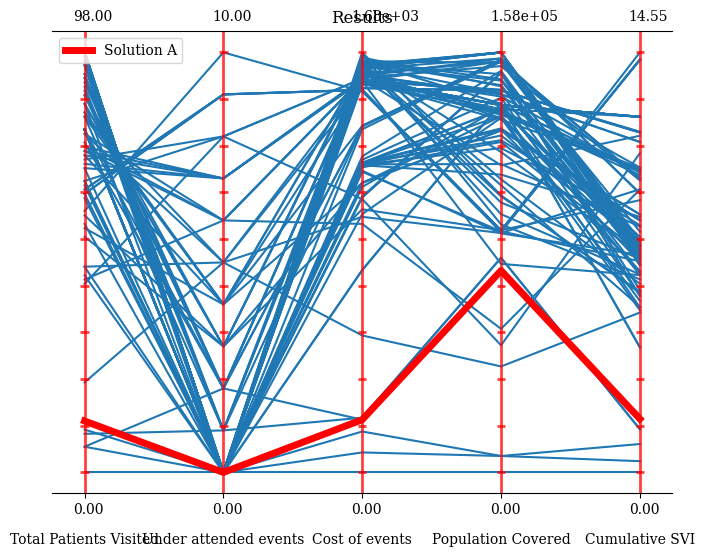

In [ ]:
from pymoo.visualization.pcp import PCP
plot = PCP(title=("Results"),
           n_ticks=10,
           legend=(True, {'loc': "upper left"}),
           labels=["Total Patients Visited", "Under attended events", "Cost of events", "Population Covered", "Cumulative SVI"]
           )

solution_to_examine = 2
plot.add(pf)
plot.add(pf[solution_to_examine,:], linewidth=5, color="red", label="Solution A").show()


## Correlation matrix

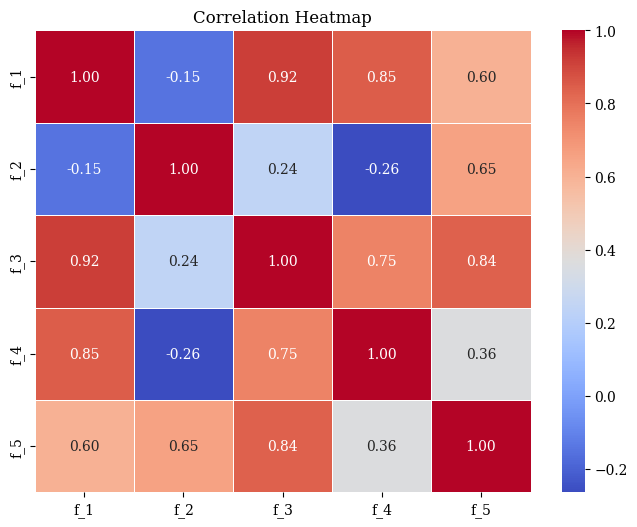

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_mat = nd_df.to_pandas().iloc[:,0:5].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_mat, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

## Helper functions

In [ ]:
# Function to determine marker size based on population
def get_marker_size(population):
    return max(5, population / 1000)  # Adjust the divisor to scale marker size

def create_color_dict(cities, ev_cities, cc): 
    marker_color = {}
    for city in cities.loc[:,"city"]: 
        if city in ev_cities: 
            marker_color[city] = "orange"
        elif city in cc: 
            marker_color[city] = "yellow"
        else: 
            marker_color[city] = "grey"

    return marker_color

def select_point(results, sol_id): 

    return {
        "f_1": int(results.loc[sol_id, "Total patients served"]),
        "f_2": int(results.loc[sol_id, "# of visited sites that are under-attended"]),
        "f_3": float(results.loc[sol_id, "Total costs ($)"]),
        "f_4": float(results.loc[sol_id, "% pop with clinic access"]),
        "f_5": float(results.loc[sol_id, "Cumulative SVI"]),
        }


def clean_results(raw_results, intermediate_point=True): 
    # Transform objectives
    if intermediate_point: 
        results = pd.DataFrame(raw_results.intermediate_points)
    else:
        results = pd.DataFrame(raw_results.optimal_objectives)

    results = results.rename(columns={
                    "f_1": "Total patients served", 
                    "f_2": "# of visited sites that are under-attended", 
                    "f_3": "Total costs ($)", 
                    "f_4": "% pop with clinic access", 
                    "f_5": "Cumulative SVI"})

    results[["Total patients served"]] =  results[["Total patients served"]].astype(int)
    results[["Total costs ($)"]] = (results[["Total costs ($)"]]).round(2)
    results[["Cumulative SVI"]] = (results[["Cumulative SVI"]]).round(2)
    results[["% pop with clinic access"]] = ((results[["% pop with clinic access"]]/total_pop)*100).round(2)

    results.index.name = "Solution ID"

    return results

## Calculate HV

In [ ]:
from pymoo.indicators.hv import HV

ref_point = np.array(list(nadir_point.values()))
ref_point[0] = -ref_point[0]
ref_point[3] = -ref_point[3]
ref_point[4] = -ref_point[4]

ind = HV(ref_point=ref_point)

int(ind(pf))

0

## Run eNAUTILUS 
### Round 1
We're going to generate some solutions. They will be poor at first, but you and the computer will slowly find the best solution that fulfills your goals and preferences. 


In [43]:
# Initialize a first solution 
from desdeo.mcdm.enautilus import enautilus_step
from desdeo.mcdm.enautilus import enautilus_get_representative_solutions

current_iter = 0
selected_point = nadir_point
total_iterations = 3
display(f"Starting with point {selected_point}")

prob.get_ideal_point()

raw_results = enautilus_step(
    problem=prob,
    non_dominated_points=nd_df,
    current_iteration=current_iter,
    iterations_left=total_iterations - current_iter,
    selected_point=selected_point,
    reachable_point_indices=reachable_indices,
    total_number_of_iterations=total_iterations,
    number_of_intermediate_points=4,
)

print(f"number of iterations left: {total_iterations - current_iter}")

results = clean_results(raw_results)
display("Which solution to do you prefer?")
display(results)

"Starting with point {'f_1': 0.0, 'f_2': 10.0, 'f_3': 1681.6653333333334, 'f_4': 0.0, 'f_5': 0.0}"

number of iterations left: 3


'Which solution to do you prefer?'

,Total patients served,# of visited sites that are under-attended,Total costs ($),% pop with clinic access,Cumulative SVI
Solution ID,,,,,
0,2,6.666667,1147.78,1.28,0.13
1,14,9.333333,1485.92,9.88,3.69
2,29,7.333333,1651.60,29.38,3.82
3,18,7.666667,1472.27,18.82,3.14


### Round 2 

In [44]:
chosen_solution = 2

In [45]:
# Refine solution based on feedback
current_iter += 1
selected_point = select_point(results, chosen_solution)

print(selected_point)

raw_results = enautilus_step(
    problem=prob,
    non_dominated_points=nd_df,
    current_iteration=current_iter,
    iterations_left=total_iterations - current_iter,
    selected_point=selected_point,
    reachable_point_indices=reachable_indices,
    total_number_of_iterations=total_iterations,
    number_of_intermediate_points=4,
)

print(f"number of iterations left: {total_iterations - current_iter}")
display(raw_results)
results = clean_results(raw_results)
display("Which solution to do you find most preferable?")
display(results)
display("Results:")



{'f_1': 29, 'f_2': 7, 'f_3': 1651.6, 'f_4': 29.38, 'f_5': 3.82}
number of iterations left: 2


ENautilusResult(current_iteration=2, iterations_left=1, intermediate_points=[{'f_1': 17.5, 'f_2': 3.5, 'f_3': 865.8, 'f_4': 3100.19, 'f_5': 2.105}, {'f_1': 36.5, 'f_2': 7.5, 'f_3': 1373.01, 'f_4': 23893.19, 'f_5': 7.439933332}, {'f_1': 59.0, 'f_2': 4.5, 'f_3': 1621.5378333333333, 'f_4': 71033.69, 'f_5': 7.6358499995}, {'f_1': 42.0, 'f_2': 5.0, 'f_3': 1352.5381666666667, 'f_4': 45509.69, 'f_5': 6.6270833325}], reachable_best_bounds=[{'f_1': 48.0, 'f_2': 0.0, 'f_3': 810.0703333333333, 'f_4': 138737.0, 'f_5': 4.3342}, {'f_1': 80.0, 'f_2': 0.0, 'f_3': 994.9026666666666, 'f_4': 136498.0, 'f_5': 9.811533332}, {'f_1': 98.0, 'f_2': 0.0, 'f_3': 1159.732, 'f_4': 157763.0, 'f_5': 11.777433332}, {'f_1': 80.0, 'f_2': 0.0, 'f_3': 1023.247, 'f_4': 150825.0, 'f_5': 9.811533332}], reachable_worst_bounds=[{'f_1': 17.5, 'f_2': 3.5, 'f_3': 865.8, 'f_4': 3100.19, 'f_5': 2.105}, {'f_1': 36.5, 'f_2': 7.5, 'f_3': 1373.01, 'f_4': 23893.19, 'f_5': 7.439933332}, {'f_1': 59.0, 'f_2': 4.5, 'f_3': 1621.537833333333

'Which solution to do you find most preferable?'

,Total patients served,# of visited sites that are under-attended,Total costs ($),% pop with clinic access,Cumulative SVI
Solution ID,,,,,
0,17,3.5,865.80,1.92,2.10
1,36,7.5,1373.01,14.83,7.44
2,59,4.5,1621.54,44.08,7.64
3,42,5.0,1352.54,28.24,6.63


'Results:'

### Round 3

In [47]:
chosen_solution = 2

In [48]:
# Refine solution based on feedback
current_iter += 1
selected_point = select_point(results, chosen_solution)

print(selected_point)

raw_results = enautilus_step(
    problem=prob,
    non_dominated_points=nd_df,
    current_iteration=current_iter,
    iterations_left=total_iterations - current_iter,
    selected_point=selected_point,
    reachable_point_indices=reachable_indices,
    total_number_of_iterations=total_iterations,
    number_of_intermediate_points=4,
)

print(f"number of iterations left: {total_iterations - current_iter}")

results = clean_results(raw_results)
display("Which solution to do you find most preferable?")
display(results)




{'f_1': 59, 'f_2': 4, 'f_3': 1621.54, 'f_4': 44.08, 'f_5': 7.64}
number of iterations left: 1


'Which solution to do you find most preferable?'

,Total patients served,# of visited sites that are under-attended,Total costs ($),% pop with clinic access,Cumulative SVI
Solution ID,,,,,
0,6,0.0,80.00,3.83,0.39
1,44,8.0,1094.42,29.64,11.06
2,89,2.0,1591.48,88.14,11.45
3,55,3.0,1053.48,56.47,9.43


## Display final result

In [49]:
final_chosen_solution = 2

In [50]:
# Get final solution 
solutions = enautilus_get_representative_solutions(prob, raw_results, nd_df) 
solution = solutions[final_chosen_solution]
results = clean_results(solution, intermediate_point=False)

display(results)
 


,Total patients served,# of visited sites that are under-attended,Total costs ($),% pop with clinic access,Cumulative SVI
Solution ID,,,,,
0,89,2.0,1591.48,88.14,11.45


### Result postprocessing

In [51]:
# Post process result...
raw_sites = solution.optimal_variables['sv'][0].to_list()
raw_sites = [[bool(e) for e in raw_sites]]

raw_coverage = solution.optimal_variables['cover'][0].to_list()
raw_coverage = [[bool(c) for c in raw_coverage]]

sites_visited = []
for evb in raw_sites: 
    sites_visited.append("\n".join(sites.loc[evb, "site_id"].values))

cities_covered = [] 
for cc in raw_coverage: 
    cities_covered.append("\n".join(cities.loc[cc,"city"].values))

results["Sites Visited"] = sites_visited
results["Cities covered"] = cities_covered

results

,Total patients served,# of visited sites that are under-attended,Total costs ($),% pop with clinic access,Cumulative SVI,Sites Visited,Cities covered
Solution ID,,,,,,,
0,89,2.0,1591.48,88.14,11.45,lima-saint-marks-umc\nmarion-grace-clinics\nli...,Ada\nAlger\nCairo\nColumbus Grove\nCridersvill...


### Map preprocessing

In [52]:
# Process for the map
sites_in_cities = sites.loc[raw_sites[0],:].groupby("city").agg({"site_pretty": lambda e : '<br>'.join(e)})
sites_in_cities = sites_in_cities.to_dict()['site_pretty']
sites_in_cities

# cc cities covered
cc = set(cities_covered[0].split('\n'))

site_cities = list(sites.loc[raw_sites[0], "city"])
marker_colors = create_color_dict(cities, site_cities, cc)


## Site coverage dictionary 
site2city_mat = cities_adj2sites[raw_sites[0]].astype(bool)

site2city_dict = {}
for (c,city) in enumerate(site_cities): 
    site2city_dict[city] = set(cities.loc[site2city_mat[c,],"city"]) - {city}

adjacent_sites = {}
# Record what sites are near other cities
for site_city in site2city_dict.keys(): 
    adj_cities = site2city_dict[site_city]
    from_name = cities.loc[cities.loc[:,"city"] == site_city,["city"]].values.tolist()[0][0]

    for adj_city in adj_cities: 
        to_name = cities.loc[cities.loc[:,"city"] == adj_city ,["city"]].values.tolist()[0][0]

        if to_name not in adjacent_sites.keys(): 
            adjacent_sites[to_name] = {from_name}
        else: 
            adjacent_sites[to_name] = adjacent_sites[to_name].union({from_name})



## Render map

In [53]:
# Render map

# Create a base map
m = folium.Map(location=[cities['lat'].mean(), 
                         cities['long'].mean()], 
                         zoom_start=7) 

# Draw lines between 
for site_city in site2city_dict.keys(): 
    adj_cities = site2city_dict[site_city]
    from_loc = cities.loc[cities.loc[:,"city"] == site_city,["lat", "long"]].values.tolist()

    for adj_city in adj_cities: 
        to_loc = cities.loc[cities.loc[:,"city"] == adj_city ,["lat", "long"]].values.tolist()
        folium.PolyLine(
            locations=[to_loc[0], from_loc[0]],
            color="black"
        ).add_to(m)

# Set bounds
sw = cities.loc[:,['lat', 'long']].min().values.tolist()
ne = cities.loc[:,['lat', 'long']].max().values.tolist()
m.fit_bounds([sw,ne])

# Create tool tips 
tooltips = {}
for _, row in cities.iterrows():
    city = row['city']
    tooltips[city]=f"<b>{city}</b><br><b>Population:</b> {row['pop']}"

    if city in sites_in_cities.keys():
        tooltips[city]+= "<br><b>Sites with events:</b><br>"
        tooltips[city]+= sites_in_cities[city]
    else:
        tooltips[city]+= "<br><b>No Healthwise Clinics</b>"

    if city in adjacent_sites.keys(): 
        tooltips[city]+= "<br><b>Covered by events in: </b>"
        tooltips[city]+= "<br>".join(adjacent_sites[city])


# Add cities to the map
for _, row in cities.iterrows():
    city = row['city']
    folium.CircleMarker(
        location=(row['lat'], row['long']),
        radius=get_marker_size(row['pop']),
        color="black",
        fill=True,
        fill_color=marker_colors[city],
        fill_opacity=0.6,
        tooltip=tooltips[city]
    ).add_to(m)

display(results)
display(m)

,Total patients served,# of visited sites that are under-attended,Total costs ($),% pop with clinic access,Cumulative SVI,Sites Visited,Cities covered
Solution ID,,,,,,,
0,89,2.0,1591.48,88.14,11.45,lima-saint-marks-umc\nmarion-grace-clinics\nli...,Ada\nAlger\nCairo\nColumbus Grove\nCridersvill...
